In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
from wale.CosmologyModel import *
from wale.CovarianceMatrix import *
from wale.InitializeVariables import *
from wale.VarianceCalculator import *
from wale.FilterFunctions import *
from wale.CommonUtils import *
from wale.CriticalPoints import *
from wale.ComputePDF import *
from wale.LoadSimulations import *

import cProfile, pstats


In [ ]:
cosmogrid_kappa = np.load("../data/all_kappas_halofit_nobaryons_bin4_theta20.0.npy")
cosmogrid_l1norms = np.load("../data/all_l1_norms_halofit_nobaryons_bin4_theta20.0.npy")
cosmogrid_variances = np.load("../data/all_variances_halofit_nobaryons_bin4_theta20.0.npy")

cosmogrid_kappa = np.load("../data/all_kappas_halofit_nobaryons_bin4.npy")
cosmogrid_l1norms = np.load("../data/all_l1_norms_halofit_nobaryons_bin4.npy")
cosmogrid_variances = np.load("../data/all_variances_halofit_nobaryons_bin4.npy")
cosmogrid_params = np.load("../data/selected_params_halofit.npy")

cosmogrid_snr = cosmogrid_kappa / (cosmogrid_variances[:, np.newaxis] ** 0.5)

print(cosmogrid_kappa.shape, cosmogrid_l1norms.shape, cosmogrid_variances.shape, cosmogrid_params.shape, cosmogrid_snr.shape)

id_zbin = 3  # Corresponds to the third redshift bin
nz_file = f"/Users/vilasini/Documents/WALE/data/nz/nz_stage3_{id_zbin+1}_GRID.txt"
print(f"Using n(z) file: {nz_file}")
theta1_input = 30.0  # Smoothing scale in arcmin
filter_type = 'tophat'

invalid_index = []
predictionl1 = []
predictionl1snr = []
cosmogrid=True


params = cosmogrid_params        # shape (1299, 6)

# find unique cosmologies
unique_params, inv = np.unique(params, axis=0, return_inverse=True)

# inv is an array of length 1299 giving the group number (0..185)
# Build a list of index groups
groups = [np.where(inv == i)[0] for i in range(len(unique_params))]
n_cosmo = len(groups)  # = 186

print(f"Found {n_cosmo} unique cosmologies from {len(params)} total realizations.")

kappa_fix = np.linspace(-0.04, 0.04, 1000)
snr_fix   = np.linspace(-4,  4,   1000)

cosmogrid_l1norm_mean_kappa = []
cosmogrid_l1norm_mean_snr   = []
cosmogrid_l1norm_std_kappa  = []
cosmogrid_l1norm_std_snr    = []
cosmogrid_variance_mean     = []
cosmogrid_variance_std      = []
cosmogrid_l1norms_kappafix = []
cosmogrid_l1norms_snrfix   = []

for idx in groups:

    l1_group   = cosmogrid_l1norms[idx]
    k_group    = cosmogrid_kappa[idx]
    snr_group  = cosmogrid_snr[idx]
    var_group  = cosmogrid_variances[idx]

    # --- interpolate each realisation to fixed kappa grid ---
    interp_kappa = np.array([
        np.interp(kappa_fix, k_group[j], l1_group[j])
        for j in range(len(idx))
    ])

    # --- interpolate each realisation to fixed snr grid ---
    interp_snr = np.array([
        np.interp(snr_fix, snr_group[j], l1_group[j])
        for j in range(len(idx))
    ])
    for j in range(len(idx)):
        # STORE FULL arrays (all realisations)
        cosmogrid_l1norms_kappafix.append(
            np.interp(kappa_fix, k_group[j], l1_group[j])
        )
        cosmogrid_l1norms_snrfix.append(
            np.interp(snr_fix, snr_group[j], l1_group[j])
        )

    # MEAN/STD across realisations
    cosmogrid_l1norm_mean_kappa.append(interp_kappa.mean(axis=0))
    cosmogrid_l1norm_mean_snr.append(interp_snr.mean(axis=0))
    cosmogrid_l1norm_std_kappa.append(interp_kappa.std(axis=0))
    cosmogrid_l1norm_std_snr.append(interp_snr.std(axis=0))
    cosmogrid_variance_mean.append(var_group.mean())
    cosmogrid_variance_std.append(var_group.std())

# convert to arrays
cosmogrid_l1norms_kappafix = np.array(cosmogrid_l1norms_kappafix)  # shape (n_cosmo, n_real, 50)
cosmogrid_l1norms_snrfix   = np.array(cosmogrid_l1norms_snrfix)    # shape (n_cosmo, n_real, 50)

cosmogrid_l1norm_mean_kappa = np.array(cosmogrid_l1norm_mean_kappa)
cosmogrid_l1norm_mean_snr   = np.array(cosmogrid_l1norm_mean_snr)
cosmogrid_l1norm_std_kappa  = np.array(cosmogrid_l1norm_std_kappa)
cosmogrid_l1norm_std_snr    = np.array(cosmogrid_l1norm_std_snr)
cosmogrid_variance_mean     = np.array(cosmogrid_variance_mean)
cosmogrid_variance_std      = np.array(cosmogrid_variance_std)




(1299, 500) (1299, 500) (1299,) (1299, 6) (1299, 500)
Using n(z) file: /Users/vilasini/Documents/WALE/data/nz/nz_stage3_4_GRID.txt
Found 186 unique cosmologies from 1299 total realizations.


In [ ]:
data = np.load("cosmo_parallel_results_bin4_theta30.npz", allow_pickle=True)
results_ = data["results"]
results_ = results_.tolist()

indices               = [r["index"] for r in results_]
valid_flags           = [r["valid"] for r in results_]
kappa_vals_all        = [r["kappa_vals"] for r in results_]
pdf_vals_all          = [r["pdf_vals"] for r in results_]
snr_all               = [r["snr"] for r in results_]
prediction_l1_snr_all = [r["prediction_l1_snr"] for r in results_]
theory_l1_kappa_all   = [r["theory_l1_kappa"] for r in results_]
pred_stats_all        = [r["pred_stats"] for r in results_]


# --- Prepare arrays ---
prediction_l1norms_kappafix = []
prediction_l1norms_snrfix   = []

# Loop over cosmology groups in same order as cosmogrid
for idx in groups:

    # Extract all realisations for this cosmology
    pred_l1_kappa_group = [theory_l1_kappa_all[i]   for i in idx]  # list of arrays
    pred_l1_snr_group   = [prediction_l1_snr_all[i] for i in idx]  # list of arrays
    kappa_vals_group    = [kappa_vals_all[i]        for i in idx]
    snr_vals_group      = [snr_all[i]               for i in idx]

    # interpolate each realisation in this cosmology
    for j in range(len(idx)):

        # kappa-based prediction
        prediction_l1norms_kappafix.append(
            np.interp(kappa_fix,
                      kappa_vals_group[j],
                      pred_l1_kappa_group[j])
        )

        # snr-based prediction
        prediction_l1norms_snrfix.append(
            np.interp(snr_fix,
                      snr_vals_group[j],
                      pred_l1_snr_group[j])
        )

# Convert to arrays (n_real=1299, 1000 bins)
prediction_l1norms_kappafix = np.array(prediction_l1norms_kappafix)
prediction_l1norms_snrfix   = np.array(prediction_l1norms_snrfix)

print(prediction_l1norms_kappafix.shape)   # (1299, 1000)
print(prediction_l1norms_snrfix.shape)     # (1299, 1000)



(1299, 1000)
(1299, 1000)


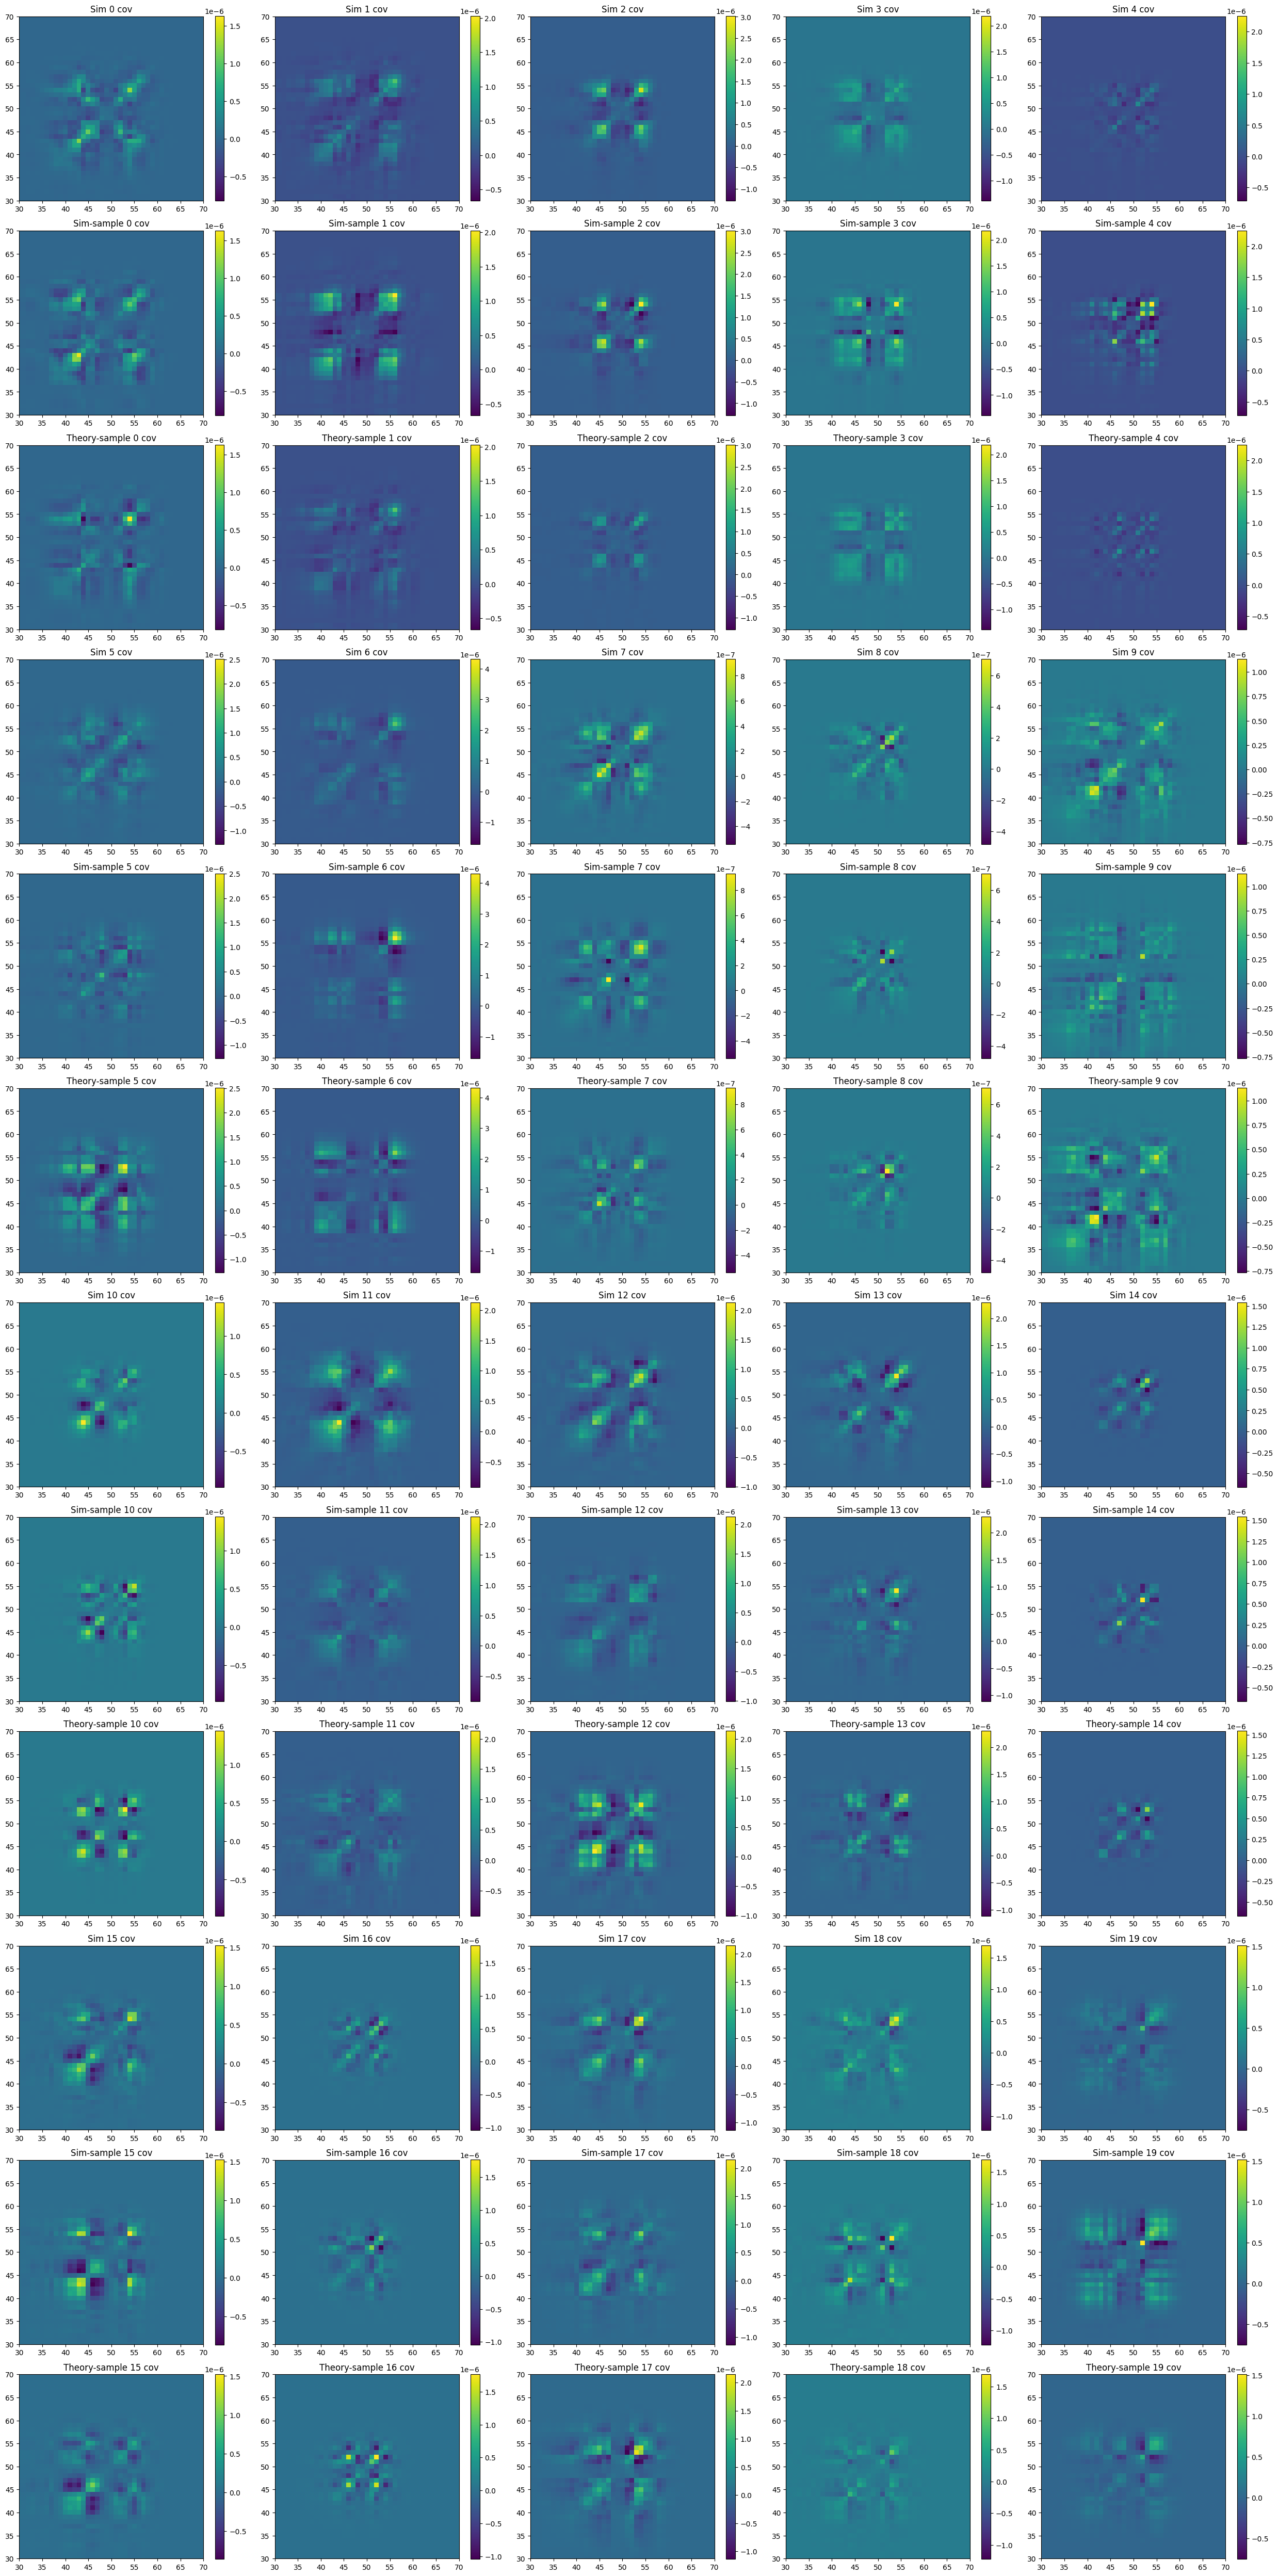

In [7]:

# ============================================================
# 1) Build simulation-based L1 rebinned, sim means, sim covariances
# ============================================================

covs_simsample = []
l1s_simsample = []
l1s_mean_sim = []

for group in groups:
    # l1 norms on fixed kappa grid (shape: n_real, 1000)
    l1s = cosmogrid_l1norms_kappafix[group]

    # Rebin: from 1000 → d = 100 (binning by factor 10)
    l1s_reshaped = l1s.reshape(l1s.shape[0], -1, 10).mean(axis=2)

    l1s_simsample.append(l1s_reshaped)

    # Covariance (d x d)
    cov = np.cov(l1s_reshaped.T)
    covs_simsample.append(cov)

    # Mean vector (d,)
    l1s_mean_sim.append(l1s_reshaped.mean(axis=0))


covs_simsample = np.array(covs_simsample)     # (n_cosmo, d, d)
l1s_mean_sim   = np.array(l1s_mean_sim)       # (n_cosmo, d)



# ============================================================
# 2) Sampling using SIM mean + SIM covariance
# ============================================================

nsamples = 7

sample_covs_sim = []
sample_l1s_sim  = []

for idx in range(len(groups)):
    mu    = l1s_mean_sim[idx]          # simulation mean
    Sigma = covs_simsample[idx]        # simulation covariance

    samples = np.random.multivariate_normal(mu, Sigma, size=nsamples)

    sample_l1s_sim.append(samples)
    sample_covs_sim.append(np.cov(samples, rowvar=False))

sample_l1s_sim  = np.array(sample_l1s_sim)     # (n_cosmo, nsamples, d)
sample_covs_sim = np.array(sample_covs_sim)    # (n_cosmo, d, d)



# ============================================================
# 3) Compute THEORY L1 rebinned + theory mean per cosmology
# ============================================================

prediction_l1s_mean = []

for group in groups:
    preds = prediction_l1norms_kappafix[group]         # (n_real, 1000)
    preds_rebinned = preds.reshape(preds.shape[0], -1, 10).mean(axis=2)  # (n_real, d)
    prediction_l1s_mean.append(preds_rebinned.mean(axis=0))

prediction_l1s_mean = np.array(prediction_l1s_mean)    # (n_cosmo, d)



# ============================================================
# 4) Sampling using THEORY mean + SIM covariance
# ============================================================

sample_covs_theory = []
sample_l1s_theory  = []

for idx in range(len(groups)):
    mu_theory = prediction_l1s_mean[idx]      # theory mean (d,)
    Sigma_sim = covs_simsample[idx]           # simulation covariance (d,d)

    samples = np.random.multivariate_normal(mu_theory, Sigma_sim, size=nsamples)

    sample_l1s_theory.append(samples)
    sample_covs_theory.append(np.cov(samples, rowvar=False))

sample_l1s_theory  = np.array(sample_l1s_theory)       # (n_cosmo, nsamples, d)
sample_covs_theory = np.array(sample_covs_theory)      # (n_cosmo, d, d)



# ============================================================
# 5) PLOTTING — 3 rows per block, 4 blocks vertically, 5 cosmo per block
# ============================================================

fig, ax = plt.subplots(12, 5, figsize=(25, 50))

for i in range(4):           # 4 blocks vertically
    for j in range(5):       # 5 cosmologies per block horizontally

        idx = i*5 + j        # cosmology index

        # Common vmin/vmax across the 3 rows
        vmin = min(
            covs_simsample[idx].min(),
            sample_covs_sim[idx].min(),
            sample_covs_theory[idx].min()
        )
        vmax = max(
            covs_simsample[idx].max(),
            sample_covs_sim[idx].max(),
            sample_covs_theory[idx].max()
        )

        # -------- Row 1: Simulation covariance --------
        r = 3*i
        im = ax[r, j].imshow(covs_simsample[idx], origin='lower', vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax[r, j])
        ax[r, j].set_title(f"Sim {idx} cov")
        ax[r, j].set_xlim(30, 70)
        ax[r, j].set_ylim(30, 70)

        # -------- Row 2: Sim-mean sampled covariance --------
        r = 3*i + 1
        im = ax[r, j].imshow(sample_covs_sim[idx], origin='lower', vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax[r, j])
        ax[r, j].set_title(f"Sim-sample {idx} cov")
        ax[r, j].set_xlim(30, 70)
        ax[r, j].set_ylim(30, 70)

        # -------- Row 3: Theory-mean sampled covariance --------
        r = 3*i + 2
        im = ax[r, j].imshow(sample_covs_theory[idx], origin='lower', vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax[r, j])
        ax[r, j].set_title(f"Theory-sample {idx} cov")
        ax[r, j].set_xlim(30, 70)
        ax[r, j].set_ylim(30, 70)

plt.tight_layout()
plt.show()


In [8]:
sample_l1s_theory.shape

(186, 7, 100)

In [9]:
np.save("sample_l1s_theory_bin4_theta30.npy", sample_l1s_theory)

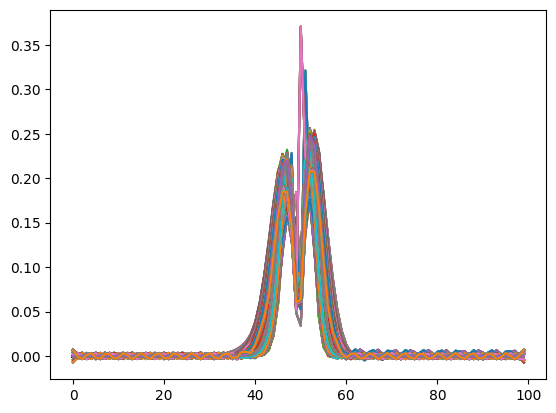

0

In [26]:
counter = 0
for i in range(186):
    if np.any(sample_l1s_theory[i] < -1e-2):
        counter += 1
        continue
    plt.plot(sample_l1s_theory[i].T)
    # plt.plot(prediction_l1norms_kappafix[i].T, alpha=0.3)
    # plt.plot(theory_l1_kappa_all[i].T, alpha=0.5)
plt.show()
counter

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
from wale.CosmologyModel import *
from wale.CovarianceMatrix import *
from wale.InitializeVariables import *
from wale.VarianceCalculator import *
from wale.FilterFunctions import *
from wale.CommonUtils import *
from wale.CriticalPoints import *
from wale.ComputePDF import *
from wale.LoadSimulations import *

import cProfile, pstats


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
datafile = np.load("/Users/vilasini/Documents/WALE/notebooks/cosmo_parallel_results_bin4_theta30.npz", allow_pickle=True)

data = datafile["results"]

results = data.tolist()             # convert to list of python dicts

cosmo_id = np.array([r["cosmo_id"] for r in results])

Om      = np.array([r["params"]["Om"]      for r in results])
sigma8  = np.array([r["params"]["sigma8"]  for r in results])
w       = np.array([r["params"]["w"]       for r in results])
h       = np.array([r["params"]["h"]       for r in results])
ns      = np.array([r["params"]["ns"]      for r in results])
Ob      = np.array([r["params"]["Ob"]      for r in results])
Oc      = np.array([r["params"]["Oc"]      for r in results])
wa      = np.array([r["params"]["wa"]      for r in results])


kappa_fix = np.array([r["kappa_fix"] for r in results], dtype=object)
snr_fix   = np.array([r["snr_fix"]   for r in results], dtype=object)


theory_l1_kappa_fix = np.array([r["theory_l1_kappa_fix"] for r in results], dtype=object)
theory_l1_snr_fix   = np.array([r["theory_l1_snr_fix"]   for r in results], dtype=object)
pred_stats          = np.array([r["pred_stats"]          for r in results], dtype=object)

cg_l1_kappa_mean = np.array([r["cg_l1_kappa_mean"] for r in results])
cg_l1_snr_mean   = np.array([r["cg_l1_snr_mean"]   for r in results])

cg_variance_mean = np.array([r["cg_variance_mean"] for r in results])
cg_variance_std  = np.array([r["cg_variance_std"]  for r in results])

cg_l1_kappa_std = np.array([r["cg_l1_kappa_std"] for r in results])
cg_l1_snr_std   = np.array([r["cg_l1_snr_std"]   for r in results])

cg_l1_kappa_realizations = np.array(
    [r["cg_l1_kappa_realizations"] for r in results], dtype=object
)

cg_l1_snr_realizations = np.array(
    [r["cg_l1_snr_realizations"] for r in results], dtype=object
)

for i in range(len(results)):
    if np.any(theory_l1_snr_fix[i] <-1e-3):
        print(f"Skipping invalid cosmology {i}")
        continue
    plt.plot(kappa_fix[i], theory_l1_kappa_fix[i], alpha=0.3)

plt.xlim(-0.015,0.015)
plt.ylim(-0.001,0.3)

Skipping invalid cosmology 8
Skipping invalid cosmology 20
Skipping invalid cosmology 47
Skipping invalid cosmology 50
Skipping invalid cosmology 61
Skipping invalid cosmology 62
Skipping invalid cosmology 94
Skipping invalid cosmology 104
Skipping invalid cosmology 106
Skipping invalid cosmology 111
Skipping invalid cosmology 113
Skipping invalid cosmology 133
Skipping invalid cosmology 143
Skipping invalid cosmology 144
Skipping invalid cosmology 145
Skipping invalid cosmology 164
Skipping invalid cosmology 166
Skipping invalid cosmology 177
Skipping invalid cosmology 179
Skipping invalid cosmology 182


(-0.001, 0.3)

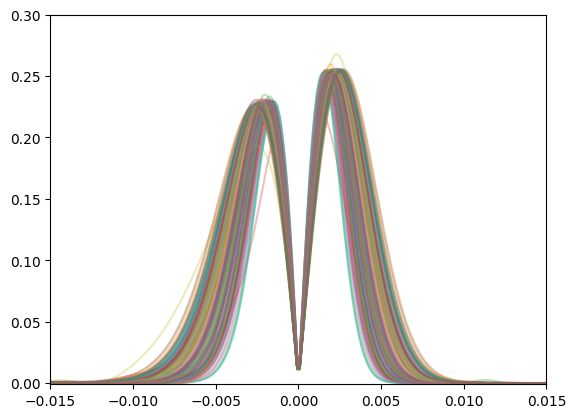

In [20]:
for i in range(len(results)):
    if np.any(theory_l1_snr_fix[i] <-1e-3):
        print(f"Skipping invalid cosmology {i}")
        continue
    plt.plot(kappa_fix[i], theory_l1_kappa_fix[i], alpha=0.3)

plt.xlim(-0.015,0.015)
plt.ylim(-0.001,0.3)

Skipping invalid cosmology 164
Skipping invalid cosmology 179
Skipping invalid cosmology 50
Skipping invalid cosmology 133
Skipping invalid cosmology 144
Skipping invalid cosmology 145
Skipping invalid cosmology 94
Skipping invalid cosmology 62
Skipping invalid cosmology 113
Skipping invalid cosmology 104
Skipping invalid cosmology 166
Skipping invalid cosmology 177
Skipping invalid cosmology 106
Skipping invalid cosmology 61
Skipping invalid cosmology 182
Skipping invalid cosmology 20
Skipping invalid cosmology 111
Skipping invalid cosmology 8
Skipping invalid cosmology 47
Skipping invalid cosmology 143


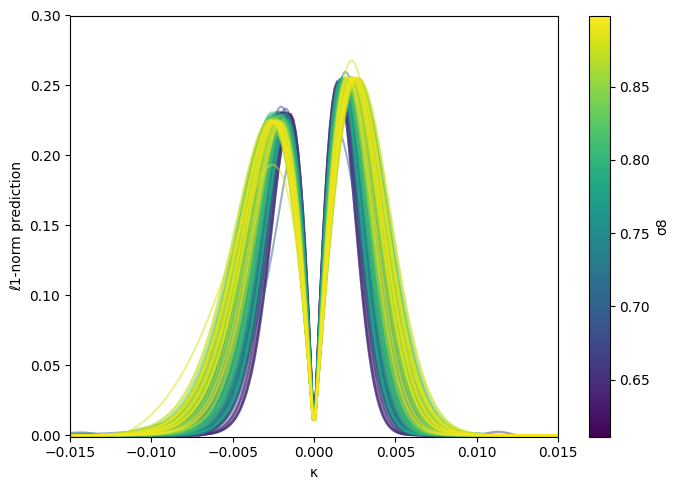

In [25]:
fig, ax = plt.subplots(figsize=(7,5))

# Sort cosmologies by increasing sigma8
order = np.argsort(sigma8)

# Make colours
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(order)))

for c, idx in zip(colors, order):

    if np.any(theory_l1_snr_fix[idx] < -1e-3):
        print(f"Skipping invalid cosmology {idx}")
        continue

    ax.plot(
        kappa_fix[idx],
        theory_l1_kappa_fix[idx],
        color=c,
        alpha=0.5
    )

ax.set_xlim(-0.015, 0.015)
ax.set_ylim(-0.001, 0.3)
ax.set_xlabel("κ")
ax.set_ylabel("ℓ1-norm prediction")

# Proper colorbar creation
norm = plt.Normalize(vmin=min(sigma8), vmax=max(sigma8))
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("σ8")

plt.tight_layout()
plt.show()


In [27]:
covs_sim = []
covs_simsample = []
l1s_theorysample = []
nsamples = 7
for i in range(len(results)):
    cov = np.cov(results[i]["cg_l1_kappa_realizations"].T)
    covs_sim.append(cov)

    mu    = results[i]["cg_l1_kappa_mean"]
    Sigma = cov

    samples = np.random.multivariate_normal(mu, Sigma, size=nsamples)

    l1s_theorysample.append(samples)
    covs_simsample.append(np.cov(samples, rowvar=False))

l1s_theorysample  = np.array(l1s_theorysample)     # (n_cosmo, nsamples, d)
covs_simsample = np.array(covs_simsample)    # (n_cosmo, d, d)


In [30]:
output = {}

for i in range(len(results)):
    # parameters
    params = results[i]["params"]

    # true realizations
    real = results[i]["cg_l1_kappa_realizations"]     # (nreal, d)
    mu   = results[i]["cg_l1_kappa_mean"]             # (d,)
    cov  = np.cov(real.T)                             # (d,d)

    # Gaussian samples from CosmoGrid covariance
    samples  = np.random.multivariate_normal(mu, cov, size=nsamples)
    cov_samp = np.cov(samples, rowvar=False)

    # store everything
    output[results[i]["cosmo_id"]] = {
        "params": {
            "Om": params["Om"],
            "sigma8": params["sigma8"],
            "w": params["w"],
            "h": params["h"],
            "ns": params["ns"],
            "Ob": params["Ob"],
            "Oc": params["Oc"],
            "wa": params["wa"],
        },

        # empirical
        "l1_realizations": real,   # true L1 realizations
        "cov_sim": cov,            # empirical covariance
        "mean_sim": mu,            # empirical mean

        # theory samples
        "l1_samples": samples,     # sampled vectors (nsamples x d)
        "cov_sampled": cov_samp,   # covariance of sampled vectors
    }


In [31]:
np.save("l1_sampling_results_theta30.npy", output, allow_pickle=True)


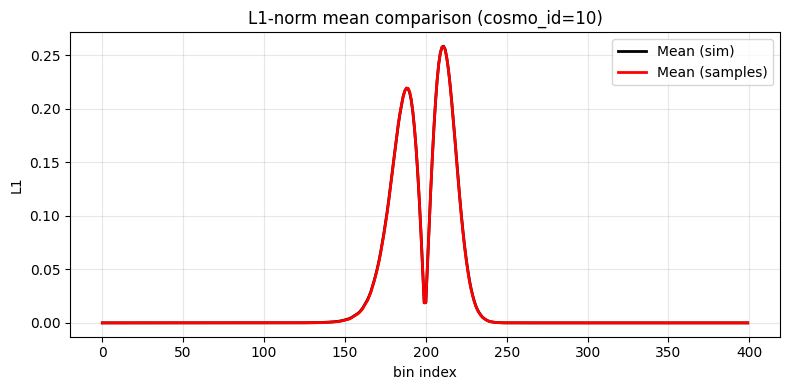

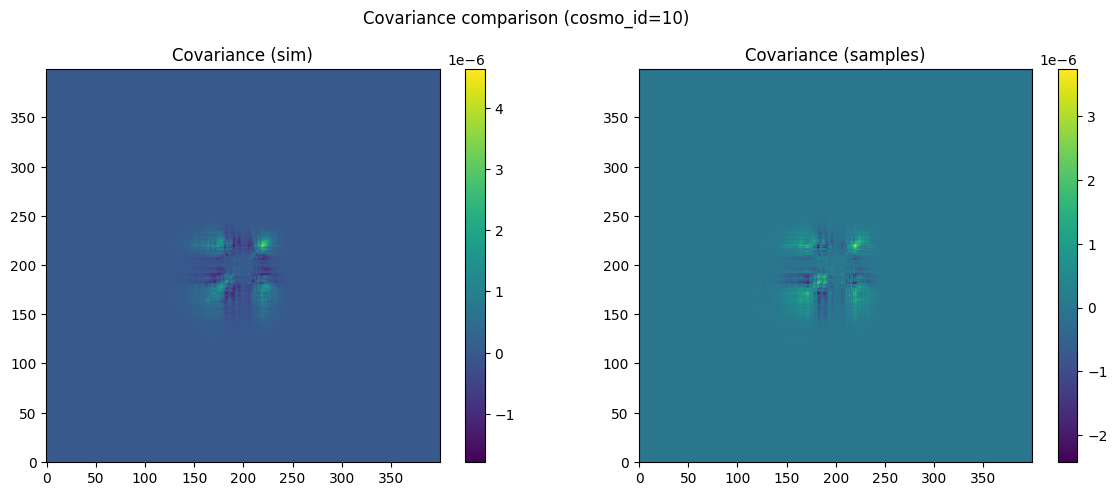

In [35]:
output = np.load("l1_sampling_results_theta30.npy", allow_pickle=True).item()
cosmo = 10   # or any valid cosmo_id key
data = output[cosmo]

real = data["l1_realizations"]     # (nreal, d)
samples = data["l1_samples"]       # (nsamples, d)

mu_real = data["mean_sim"]         # (d,)
mu_samp = samples.mean(axis=0)     # (d,)

cov_real = data["cov_sim"]         # (d,d)
cov_samp = data["cov_sampled"]     # (d,d)

plt.figure(figsize=(8,4))
plt.plot(mu_real, color='black', label='Mean (sim)', lw=2)
plt.plot(mu_samp, color='red', label='Mean (samples)', lw=2)
plt.title(f"L1-norm mean comparison (cosmo_id={cosmo})")
plt.legend()
plt.xlabel("bin index")
plt.ylabel("L1")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(1, 2, figsize=(12,5))

im0 = ax[0].imshow(cov_real, origin='lower')
ax[0].set_title("Covariance (sim)")
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(cov_samp, origin='lower')
ax[1].set_title("Covariance (samples)")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

plt.suptitle(f"Covariance comparison (cosmo_id={cosmo})")
plt.tight_layout()
plt.show()
